# Flowboard SaaS Funnel Analysis
## Notebook 2: Findings & Recommendations

**Analyst:** Alaz Peker-Röhrig  
**Date:** March 2026  

---

This notebook presents the key findings from the funnel analysis with presentation-ready visualizations and translates them into concrete business recommendations.

For the full technical pipeline (data cleaning, EDA, queries), see Notebook 1.

---

**Executive Summary:**

The biggest constraint in the funnel is early-stage conversion. Most users drop off before signing up, and mobile performance is significantly worse than desktop. At the same time, users who make it further into the product (especially those coming from referrals or completing onboarding) convert well.

This suggests two priorities:

1. reduce friction at sign-up, especially on mobile,
2. improve activation to capture more value from users who already enter the funnel.

---
## Setup

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import sqlite3
import warnings

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (12, 6),
    'figure.dpi': 100,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

COLORS = {
    'primary': '#2563EB',
    'secondary': '#64748B',
    'accent': '#F59E0B',
    'success': '#10B981',
    'danger': '#EF4444',
}

conn = sqlite3.connect('c:/Users/alazp/Desktop/SaaS_Funnel_Analysis/flowboard.db')

---
## The Full Funnel at a Glance

Over 6 months, Flowboard's self-serve funnel converted 5.3% of website visitors into paid subscribers. The two biggest leaks are at the top (visit → sign-up) and the bottom (activation → subscription).

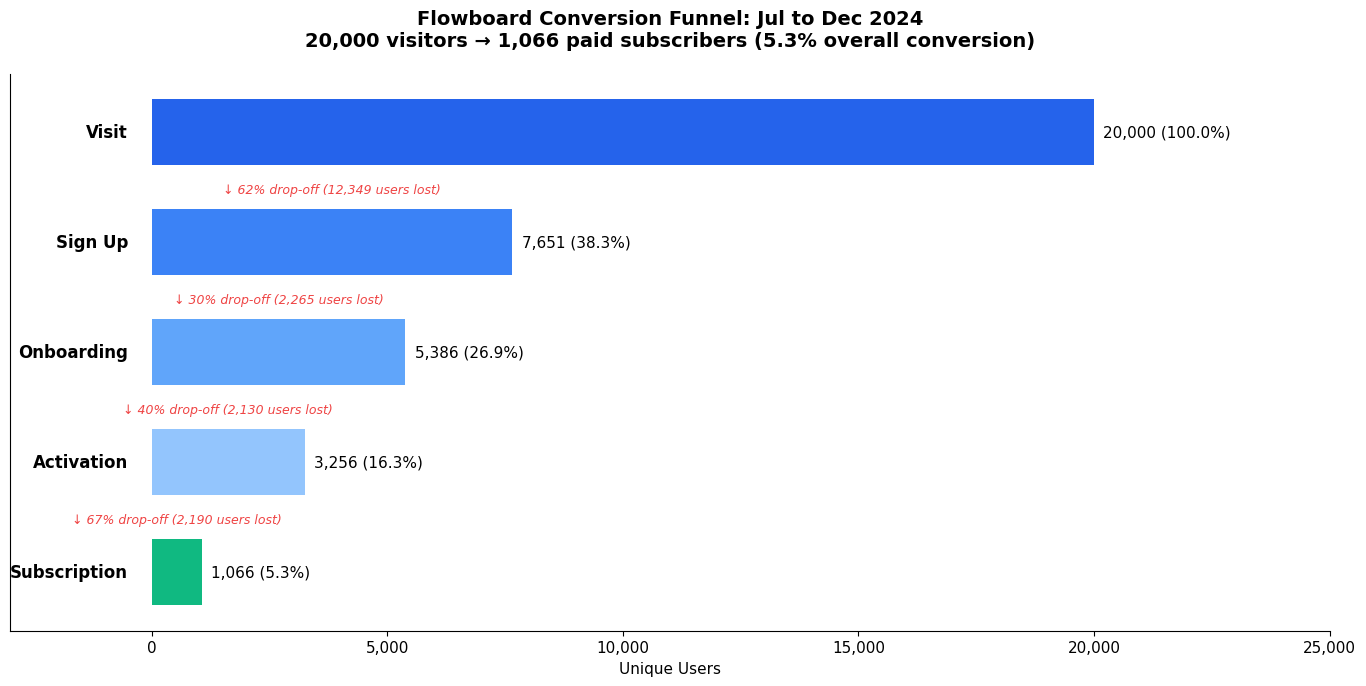

In [37]:
funnel = pd.read_sql("""
    SELECT event_name, COUNT(DISTINCT user_id) AS users
    FROM events_clean WHERE event_type = 'funnel' GROUP BY event_name
    ORDER BY CASE event_name
        WHEN 'visit_landing_page' THEN 1 WHEN 'sign_up' THEN 2
        WHEN 'complete_onboarding' THEN 3 WHEN 'activate_feature' THEN 4
        WHEN 'subscribe_paid' THEN 5 END
""", conn)

labels = ['Visit', 'Sign Up', 'Onboarding', 'Activation', 'Subscription']
users = funnel['users'].values
total = users[0]
dropoffs = [0] + [users[i-1] - users[i] for i in range(1, len(users))]

fig, ax = plt.subplots(figsize=(14, 7))

bar_colors = ['#2563EB', '#3B82F6', '#60A5FA', '#93C5FD', '#10B981']
bars = ax.barh(range(len(labels)-1, -1, -1), users, color=bar_colors, height=0.6)

for i, (bar, label, u) in enumerate(zip(bars, labels, users)):
    pct = u / total * 100
    ax.text(-500, bar.get_y() + bar.get_height() / 2,
            label, va='center', ha='right', fontsize=12, fontweight='bold')
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height() / 2,
            f'{u:,} ({pct:.1f}%)', va='center', fontsize=11)
    if i > 0:
        drop_pct = (1 - u / users[i-1]) * 100
        ax.text(u / 2, bar.get_y() + bar.get_height() + 0.15,
                f'↓ {drop_pct:.0f}% drop-off ({dropoffs[i]:,} users lost)',
                ha='center', fontsize=9, color=COLORS['danger'], style='italic')

ax.set_yticks([])
ax.set_xlim(-3000, total * 1.25)
ax.set_xlabel('Unique Users')
ax.set_title('Flowboard Conversion Funnel: Jul to Dec 2024\n20,000 visitors → 1,066 paid subscribers (5.3% overall conversion)',
             fontsize=14, fontweight='bold', pad=20)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.savefig('C:/Users/alazp/Desktop/SaaS_Funnel_Analysis/charts/02_executive_funnel.png', bbox_inches='tight', dpi=150)
plt.show()

---
## Finding 1: Visit to Sign-Up Is the Biggest Leak

61.7% of all visitors leave without creating an account. The single largest volume loss, representing ~12,300 lost potential users over 6 months. The activation → subscription stage has the lowest rate (32.7%), but visit → sign-up loses the most people in absolute terms.

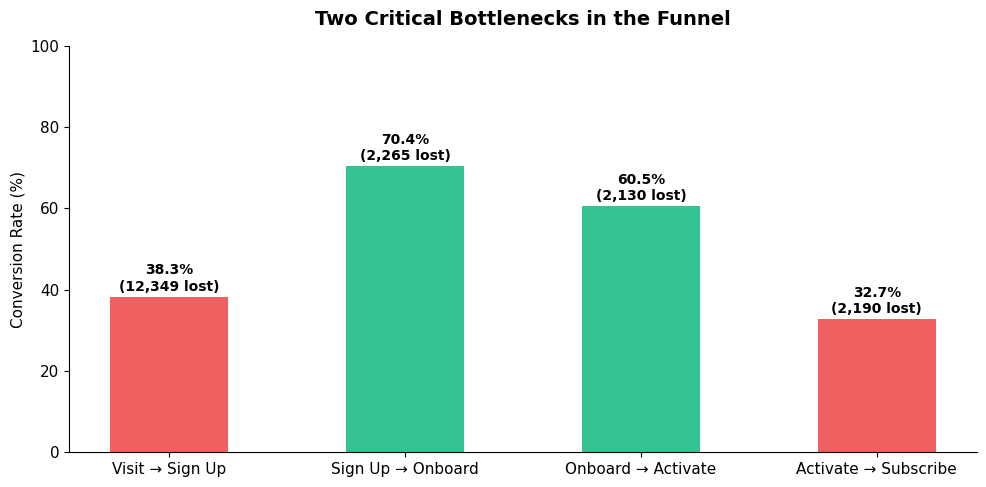

In [38]:
conv_data = pd.read_sql("""
    WITH fc AS (
        SELECT event_name, COUNT(DISTINCT user_id) AS u,
            CASE event_name WHEN 'visit_landing_page' THEN 1 WHEN 'sign_up' THEN 2
                WHEN 'complete_onboarding' THEN 3 WHEN 'activate_feature' THEN 4
                WHEN 'subscribe_paid' THEN 5 END AS o
        FROM events_clean WHERE event_type = 'funnel' GROUP BY event_name
    )
    SELECT curr.event_name, ROUND(100.0 * curr.u / prev.u, 1) AS conv,
           prev.u - curr.u AS users_lost
    FROM fc curr JOIN fc prev ON curr.o = prev.o + 1 ORDER BY curr.o
""", conn)

transitions = ['Visit → Sign Up', 'Sign Up → Onboard', 'Onboard → Activate', 'Activate → Subscribe']

fig, ax = plt.subplots(figsize=(10, 5))
colors = [COLORS['danger'], COLORS['success'], COLORS['success'], COLORS['danger']]
bars = ax.bar(transitions, conv_data['conv'].values, color=colors, width=0.5, alpha=0.85)

for bar, val, lost in zip(bars, conv_data['conv'].values, conv_data['users_lost'].values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
            f'{val}%\n({lost:,} lost)', ha='center', fontsize=10, fontweight='bold')

ax.set_ylim(0, 100)
ax.set_ylabel('Conversion Rate (%)')
ax.set_title('Two Critical Bottlenecks in the Funnel', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('C:/Users/alazp/Desktop/SaaS_Funnel_Analysis/charts/02_bottlenecks.png', bbox_inches='tight', dpi=150)
plt.show()

---
## Finding 2: Mobile Converts at 5x Lower Rate Than Desktop

Mobile accounts for 30% of traffic but only 1.6% conversion vs 8.0% on desktop. The gap exists at every funnel stage but is steepest at sign-up and onboarding, suggesting friction in the mobile registration and setup flows.

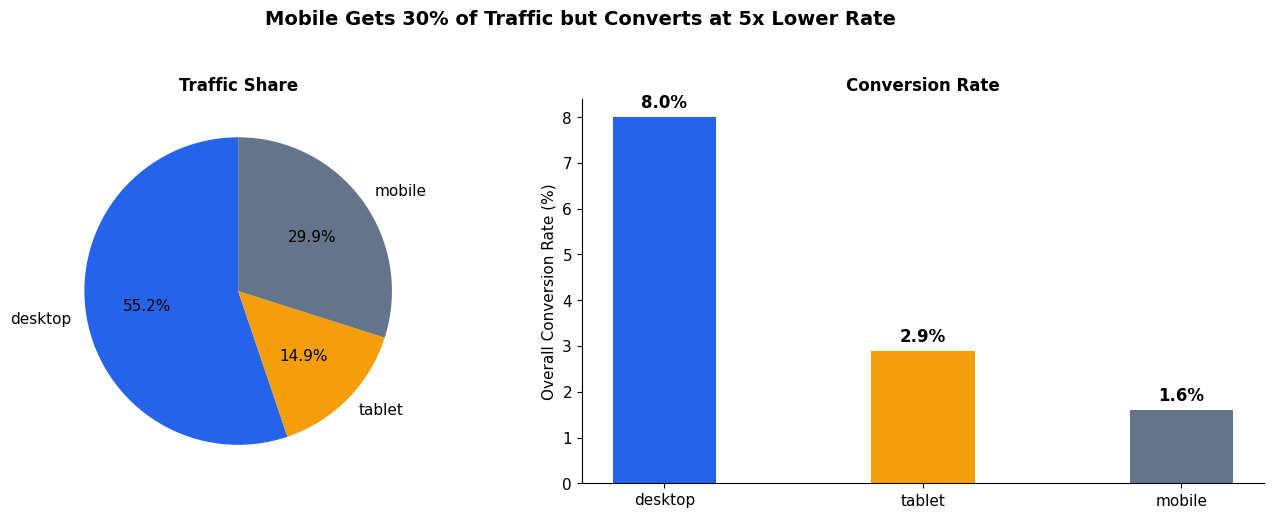

In [39]:
device_data = pd.read_sql("""
    SELECT device,
        COUNT(DISTINCT CASE WHEN event_name = 'visit_landing_page' THEN user_id END) AS visitors,
        COUNT(DISTINCT CASE WHEN event_name = 'subscribe_paid' THEN user_id END) AS subscribed,
        ROUND(100.0 * COUNT(DISTINCT CASE WHEN event_name = 'subscribe_paid' THEN user_id END) /
            NULLIF(COUNT(DISTINCT CASE WHEN event_name = 'visit_landing_page' THEN user_id END), 0), 1) AS overall_conv
    FROM events_clean WHERE event_type = 'funnel'
    GROUP BY device ORDER BY overall_conv DESC
""", conn)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

device_colors = [COLORS['primary'], COLORS['accent'], COLORS['secondary']]
ax1.pie(device_data['visitors'], labels=device_data['device'],
        autopct='%1.1f%%', colors=device_colors, startangle=90)
ax1.set_title('Traffic Share', fontsize=12, fontweight='bold')

bars = ax2.bar(device_data['device'], device_data['overall_conv'], color=device_colors, width=0.4)
for bar, val in zip(bars, device_data['overall_conv']):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
            f'{val}%', ha='center', fontsize=12, fontweight='bold')
ax2.set_ylabel('Overall Conversion Rate (%)')
ax2.set_title('Conversion Rate', fontsize=12, fontweight='bold')

fig.suptitle('Mobile Gets 30% of Traffic but Converts at 5x Lower Rate',
             fontsize=14, fontweight='bold', y=1.03)

plt.tight_layout()
plt.savefig('C:/Users/alazp/Desktop/SaaS_Funnel_Analysis/charts/02_device_gap.png', bbox_inches='tight', dpi=150)
plt.show()

---
## Finding 3: Referral Outperforms All Other Channels

Referral users convert at 12.5%: more than double any other channel and 14x the rate of social media. This indicates that users who arrive with a personal recommendation have significantly higher intent and trust.

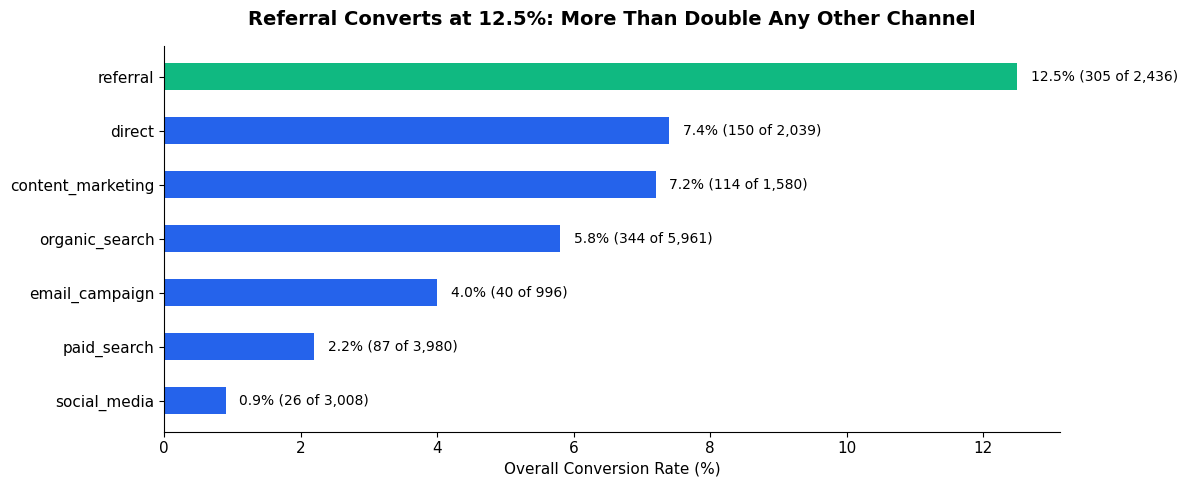

In [40]:
channel_data = pd.read_sql("""
    SELECT channel,
        COUNT(DISTINCT CASE WHEN event_name = 'visit_landing_page' THEN user_id END) AS visitors,
        COUNT(DISTINCT CASE WHEN event_name = 'subscribe_paid' THEN user_id END) AS subscribed,
        ROUND(100.0 * COUNT(DISTINCT CASE WHEN event_name = 'subscribe_paid' THEN user_id END) /
            NULLIF(COUNT(DISTINCT CASE WHEN event_name = 'visit_landing_page' THEN user_id END), 0), 1) AS overall_conv
    FROM events_clean WHERE event_type = 'funnel'
    GROUP BY channel ORDER BY overall_conv DESC
""", conn)

fig, ax = plt.subplots(figsize=(12, 5))
ch_sorted = channel_data.sort_values('overall_conv', ascending=True)
colors = [COLORS['success'] if c == 'referral' else COLORS['primary'] for c in ch_sorted['channel']]
bars = ax.barh(ch_sorted['channel'], ch_sorted['overall_conv'], color=colors, height=0.5)

for bar, visitors, subs in zip(bars, ch_sorted['visitors'], ch_sorted['subscribed']):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
            f'{bar.get_width():.1f}% ({subs:,} of {visitors:,})', va='center', fontsize=10)

ax.set_xlabel('Overall Conversion Rate (%)')
ax.set_title('Referral Converts at 12.5%: More Than Double Any Other Channel',
             fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('C:/Users/alazp/Desktop/SaaS_Funnel_Analysis/charts/02_referral.png', bbox_inches='tight', dpi=150)
plt.show()

---
## Finding 4: Mid-Size Companies Are the Self-Serve Sweet Spot

Companies with 11–200 employees convert at the highest rates. Very small teams (1–10) may not see enough team value, while enterprise (1000+) likely requires a sales-assisted process that self-serve can't provide.

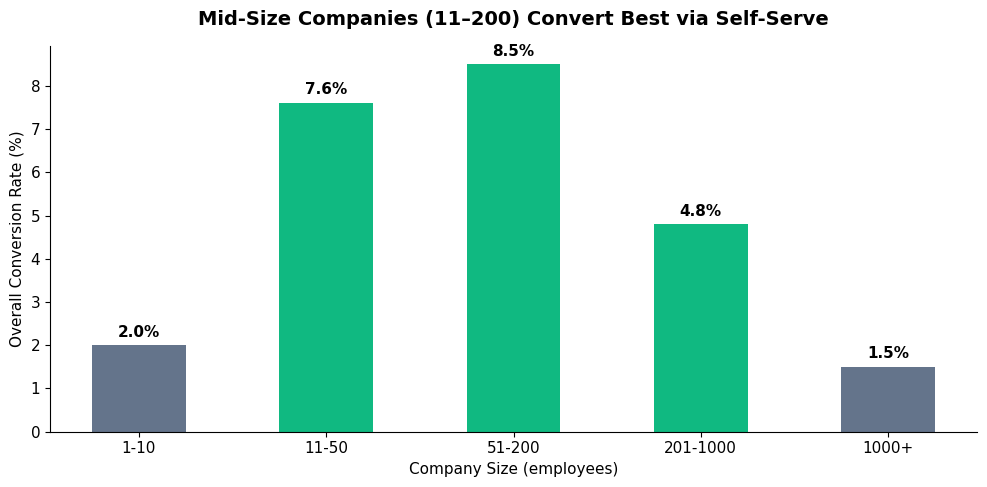

In [41]:
size_data = pd.read_sql("""
    SELECT company_size,
        COUNT(DISTINCT CASE WHEN event_name = 'visit_landing_page' THEN user_id END) AS visitors,
        COUNT(DISTINCT CASE WHEN event_name = 'subscribe_paid' THEN user_id END) AS subscribed,
        ROUND(100.0 * COUNT(DISTINCT CASE WHEN event_name = 'subscribe_paid' THEN user_id END) /
            NULLIF(COUNT(DISTINCT CASE WHEN event_name = 'visit_landing_page' THEN user_id END), 0), 1) AS overall_conv
    FROM events_clean WHERE event_type = 'funnel' GROUP BY company_size
    ORDER BY CASE company_size
        WHEN '1-10' THEN 1 WHEN '11-50' THEN 2 WHEN '51-200' THEN 3
        WHEN '201-1000' THEN 4 WHEN '1000+' THEN 5 END
""", conn)

fig, ax = plt.subplots(figsize=(10, 5))
colors = [COLORS['success'] if v >= size_data['overall_conv'].median() else COLORS['secondary']
          for v in size_data['overall_conv']]
bars = ax.bar(size_data['company_size'], size_data['overall_conv'], color=colors, width=0.5)
for bar, val in zip(bars, size_data['overall_conv']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
            f'{val}%', ha='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Company Size (employees)')
ax.set_ylabel('Overall Conversion Rate (%)')
ax.set_title('Mid-Size Companies (11–200) Convert Best via Self-Serve',
             fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('C:/Users/alazp/Desktop/SaaS_Funnel_Analysis/charts/02_company_size.png', bbox_inches='tight', dpi=150)
plt.show()

---
## Finding 5: Onboarding Completion Predicts Conversion

Users who complete all 4 onboarding steps subscribe at notably higher rates than those who skip steps. Onboarding completion is one of the strongest behavioral predictors of paid conversion.

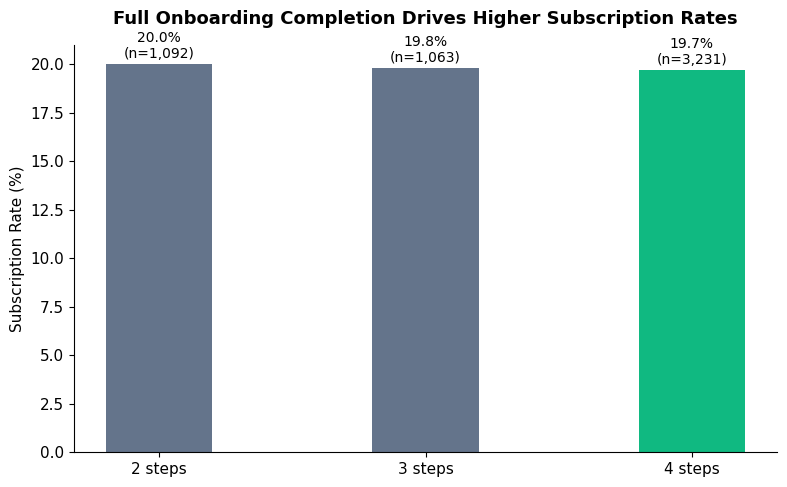

In [42]:
onboard_data = pd.read_sql("""
    WITH os AS (
        SELECT user_id, COUNT(*) AS steps
        FROM events_clean WHERE event_type = 'onboarding' GROUP BY user_id
    ),
    ua AS (SELECT DISTINCT user_id FROM events_clean WHERE event_name = 'subscribe_paid')
    SELECT os.steps, COUNT(*) AS users,
        SUM(CASE WHEN ua.user_id IS NOT NULL THEN 1 ELSE 0 END) AS subscribed,
        ROUND(100.0 * SUM(CASE WHEN ua.user_id IS NOT NULL THEN 1 ELSE 0 END) / COUNT(*), 1) AS sub_rate
    FROM os LEFT JOIN ua ON os.user_id = ua.user_id
    GROUP BY os.steps ORDER BY os.steps
""", conn)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar([f'{s} steps' for s in onboard_data['steps']], onboard_data['sub_rate'],
              color=[COLORS['secondary']] * (len(onboard_data) - 1) + [COLORS['success']], width=0.4)
for bar, val, u in zip(bars, onboard_data['sub_rate'], onboard_data['users']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{val}%\n(n={u:,})', ha='center', fontsize=10)

ax.set_ylabel('Subscription Rate (%)')
ax.set_title('Full Onboarding Completion Drives Higher Subscription Rates',
             fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('C:/Users/alazp/Desktop/SaaS_Funnel_Analysis/charts/02_onboarding.png', bbox_inches='tight', dpi=150)
plt.show()

In [43]:
conn.close()

---
## 
Objective: Identify where users drop off in the funnel, which segments perform best, and what actions would increase paid conversions.
Based on the analysis of 208K events across 20,000 users over 6 months:

## Key Findings 

### 1. Largest Loss Occurs at Visit → Sign-Up

Over 60% of users drop off before creating an account. This is the biggest loss in absolute terms.

Interpretation:
The issue is likely friction in the signup or landing experience rather than lack of interest.

### 2. Mobile Conversion Is Significantly Lower

Mobile users convert at much lower rates than desktop across the funnel.

Interpretation:
This suggests usability or performance issues on mobile rather than user intent differences.

### 3. Activation → Subscription Is a Revenue Bottleneck

Users who activate show intent, but only a portion convert to paid.

Interpretation:
Users are not fully reaching or recognizing product value before the paywall.

### 4. Referral Channel Has the Highest Conversion Rate

Referral users convert substantially better than other channels.

Interpretation:
These users likely arrive with higher trust or clearer expectations.

### 5. Onboarding Completion Strongly Correlates with Conversion

Users who complete more onboarding steps are more likely to activate and subscribe.

Interpretation:
Onboarding is a key driver of value realization, but may contain drop-off points.

---

## Recommendations

1. Improve Visit → Sign-Up Conversion **(Highest Priority)**
Reduce form complexity (fewer required fields)
Test social login options
A/B test landing page messaging and CTA placement
Align landing pages with acquisition channels

2. Fix Mobile Experience **(High Impact)**
Audit mobile signup and onboarding flow
Identify friction using session recordings or heatmaps
Test simplified mobile-first flows
Improve page load speed and responsiveness

3. Increase Activation → Subscription Conversion **(Revenue Focus)**
Add upgrade prompts after activation
Highlight key premium features earlier
Use lifecycle messaging (email / in-app nudges)
Test incentives or trial adjustments

4. Scale High-Performing Channels
Expand referral programs
Identify and strengthen top referral sources
Incorporate social proof into other channels

5. Optimize Onboarding Flow
Identify highest drop-off steps
Reduce or reorder steps to reach value faster
Test shorter or progressive onboarding
Add progress indicators or feedback

**Priority Summary:**
1. Visit → Sign-Up conversion (largest volume impact)
2. Mobile performance gap
3. Activation → Subscription (direct revenue impact)

---

## Limitations

This is a synthetic dataset designed to simulate realistic SaaS behavior. The patterns are plausible but may not reflect real-world complexity. The analysis shows correlations, not causes. It also doesn't include qualitative data like user feedback or session recordings, which would be needed to explain the "why" behind the drop-offs.

---

## Next Steps

- Cohort analysis to see if conversion improves for users acquired in later months
- A closer look at the October dip to check whether it's seasonal